In [1]:
!where python

d:\dev\github\mission16\.venv\Scripts\python.exe
C:\Users\kmw\AppData\Local\Programs\Python\Python310\python.exe
C:\Users\kmw\AppData\Local\Microsoft\WindowsApps\python.exe


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from PIL import Image
import torch.quantization as tq

In [3]:
# CPU 전용으로 통일
device = torch.device('cpu')
print(f"CPU 전용 추론 환경 설정 완료")

CPU 전용 추론 환경 설정 완료


In [4]:
# CIFAR-10 데이터셋(raw)
dataset = CIFAR10(root='./data', train=False, download=True)
cifar_classes = dataset.classes
test_targets = dataset.targets[:100]

def safe_cifar_preprocess(raw_img):
    """CIFAR-10 (H,W,C)=(32,32,3) → ResNet (1,3,224,224)"""
    # raw_img은 이미 (32,32,3) HWC 형태
    img_array = np.clip(raw_img * 255, 0, 255).astype(np.uint8)
    
    # PIL 변환 (HWC 그대로 사용)
    pil_img = Image.fromarray(img_array, mode='RGB')
    
    # ResNet 표준 전처리
    tform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),  # CHW 변환
        transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
    ])
    processed = tform(pil_img).unsqueeze(0)  # 배치 차원 추가
    
    return processed

In [5]:
# 데이터셋 생성
test_data = []
for i in range(100):
    raw_img = dataset.data[i]  # (32,32,3) HWC
    data = safe_cifar_preprocess(raw_img)
    target = test_targets[i]
    test_data.append({'data': data, 'target': target})

print(f"CIFAR-10 100개 전처리 완료")
print(f"Raw shape: {dataset.data[0].shape}")  # (32,32,3)
print(f"Processed shape: {test_data[0]['data'].shape}")  # (1,3,224,224)
print(f"샘플 정답: {cifar_classes[test_data[0]['target']]}")

CIFAR-10 100개 전처리 완료
Raw shape: (32, 32, 3)
Processed shape: torch.Size([1, 3, 224, 224])
샘플 정답: cat


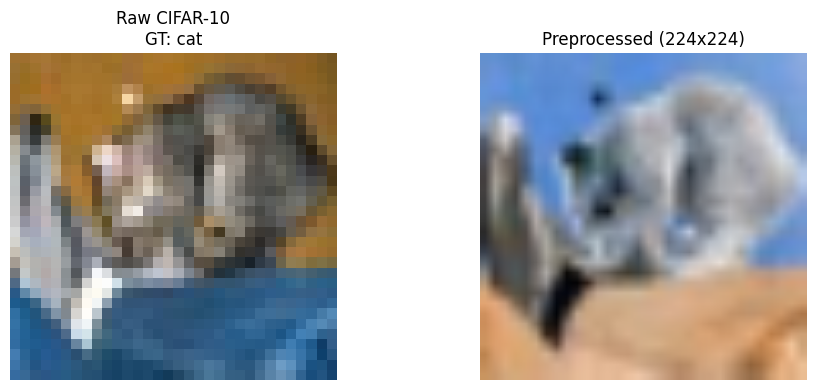

In [6]:
# 첫 번째 이미지 시각화 (numpy 브로드캐스트)
plt.figure(figsize=(10, 4))

# 1. Raw 이미지
plt.subplot(1,2,1)
plt.imshow(dataset.data[0])
plt.title(f"Raw CIFAR-10\nGT: {cifar_classes[test_targets[0]]}")
plt.axis('off')

# 2. Processed 이미지 (정규화 복원)
plt.subplot(1,2,2)
processed_img = test_data[0]['data'][0].detach().numpy()  # (3,224,224)

# 정규화 복원 (브로드캐스트 확실히)
mean = np.array([0.485, 0.456, 0.406])[:, np.newaxis, np.newaxis]  # (3,1,1)
std = np.array([0.229, 0.224, 0.225])[:, np.newaxis, np.newaxis]   # (3,1,1)
processed_img = processed_img * std + mean
processed_img = np.clip(processed_img, 0, 1)

# CHW → HWC
processed_img = np.transpose(processed_img, (1, 2, 0))

plt.imshow(processed_img)
plt.title("Preprocessed (224x224)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# 모델 로드 함수 정의
def build_fp32_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model.eval()
    return model

def build_quant_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model.eval()

    model_quant = torch.quantization.quantize_dynamic(
        model,
        {torch.nn.Linear},
        dtype=torch.qint8
    )
    model_quant.eval()
    return model_quant

def load_pytorch_fp32():
    model = build_fp32_model()
    state = torch.load('outputs/models/resnet18.pth', map_location='cpu')
    model.load_state_dict(state, strict=True)
    return model

def load_pytorch_quant():
    model = build_quant_model()
    state = torch.load('outputs/models/resnet18_quant.pth', map_location='cpu')
    model.load_state_dict(state, strict=True)
    return model

def load_onnx():
    session = ort.InferenceSession(
        'outputs/models/resnet18.onnx',
        providers=['CPUExecutionProvider']
    )
    input_name = session.get_inputs()[0].name
    return session, input_name

In [8]:
# 모델 로드
print("모델 로딩 중...")

models_info = {}

try:
    models_info['PyTorch FP32'] = load_pytorch_fp32()
    print("✅ PyTorch FP32 로드 성공")
except Exception as e:
    print(f"❌ PyTorch FP32 로드 실패: {e}")

try:
    models_info['PyTorch Quant'] = load_pytorch_quant()
    print("✅ PyTorch Quant 로드 성공")
except Exception as e:
    print(f"❌ PyTorch Quant 로드 실패: {e}")

try:
    onnx_session, onnx_input_name = load_onnx()
    models_info['ONNX'] = (onnx_session, onnx_input_name)
    print(f"✅ ONNX 로드 성공 / input_name={onnx_input_name}")
except Exception as e:
    print(f"❌ ONNX 로드 실패: {e}")

모델 로딩 중...
✅ PyTorch FP32 로드 성공


C:\Users\kmw\AppData\Local\Temp\ipykernel_27516\1451693058.py:13: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quant = torch.quantization.quantize_dynamic(
d:\dev\github\mission16\.venv\lib\site-packages\torch\_utils.py:445: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only

✅ PyTorch Quant 로드 성공
✅ ONNX 로드 성공 / input_name=input


In [9]:
# 추론 및 정확도 계산 함수 정의
def run_inference(model_type, model_info, test_data):
    """추론 + 정확도 + 시간 측정"""
    correct = 0
    total_time = 0
    model_name = model_type
    
    for item in test_data:
        data, target = item['data'], item['target']
        start_time = time.perf_counter()
        
        if model_type == 'PyTorch FP32' or model_type == 'PyTorch Quant':
            with torch.no_grad():
                output = model_info(data)
                pred = output.argmax(dim=1).item()
        else:  # ONNX
            session, input_name = model_info
            ort_inputs = {input_name: data.numpy()}
            output = session.run(None, ort_inputs)
            pred = np.argmax(output[0])
        
        inference_time = (time.perf_counter() - start_time) * 1000  # ms
        total_time += inference_time
        
        if pred == target:
            correct += 1
    
    accuracy = correct / len(test_data) * 100
    avg_time = total_time / len(test_data)
    
    return {
        'accuracy_%': accuracy,
        'avg_time_ms': avg_time,
        'correct': correct,
        'total': len(test_data)
    }

print("추론 및 정확도 계산 중...")
results = {}

for name, model in models_info.items():
    results[name] = run_inference(name, model, test_data)
    print(f"  {name}: 정확도 {results[name]['accuracy_%']:.1f}%, "
          f"평균 {results[name]['avg_time_ms']:.2f}ms "
          f"({results[name]['correct']}/{results[name]['total']})")

추론 및 정확도 계산 중...
  PyTorch FP32: 정확도 55.0%, 평균 24.75ms (55/100)
  PyTorch Quant: 정확도 55.0%, 평균 23.49ms (55/100)
  ONNX: 정확도 55.0%, 평균 9.02ms (55/100)


In [11]:
# 모델 크기 측정
model_files = {
    'PyTorch FP32': 'resnet18.pth',
    'PyTorch Quant': 'resnet18_quant.pth',
    'ONNX': 'resnet18.onnx'
}

model_sizes = {}

for name, filename in model_files.items():
    filepath = f'outputs/models/{filename}'

    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024 ** 2)

        # ONNX의 경우 .data 파일도 합산
        if name == 'ONNX':
            data_path = filepath + '.data'
            if os.path.exists(data_path):
                data_size_mb = os.path.getsize(data_path) / (1024 ** 2)
                total_size_mb = size_mb + data_size_mb
                model_sizes[name] = round(total_size_mb, 2)
                print(f"{name}: {size_mb:.2f}MB + {data_size_mb:.2f}MB(.data) = {total_size_mb:.2f}MB")
            else:
                model_sizes[name] = round(size_mb, 2)
                print(f"{name}: {size_mb:.2f}MB (.data 파일 없음)")
        else:
            model_sizes[name] = round(size_mb, 2)
            print(f"{name}: {size_mb:.2f}MB")

    else:
        print(f"{name}: {filepath} 없음")
        model_sizes[name] = 0.0

PyTorch FP32: 42.73MB
PyTorch Quant: 42.72MB
ONNX: 0.09MB + 42.69MB(.data) = 42.77MB


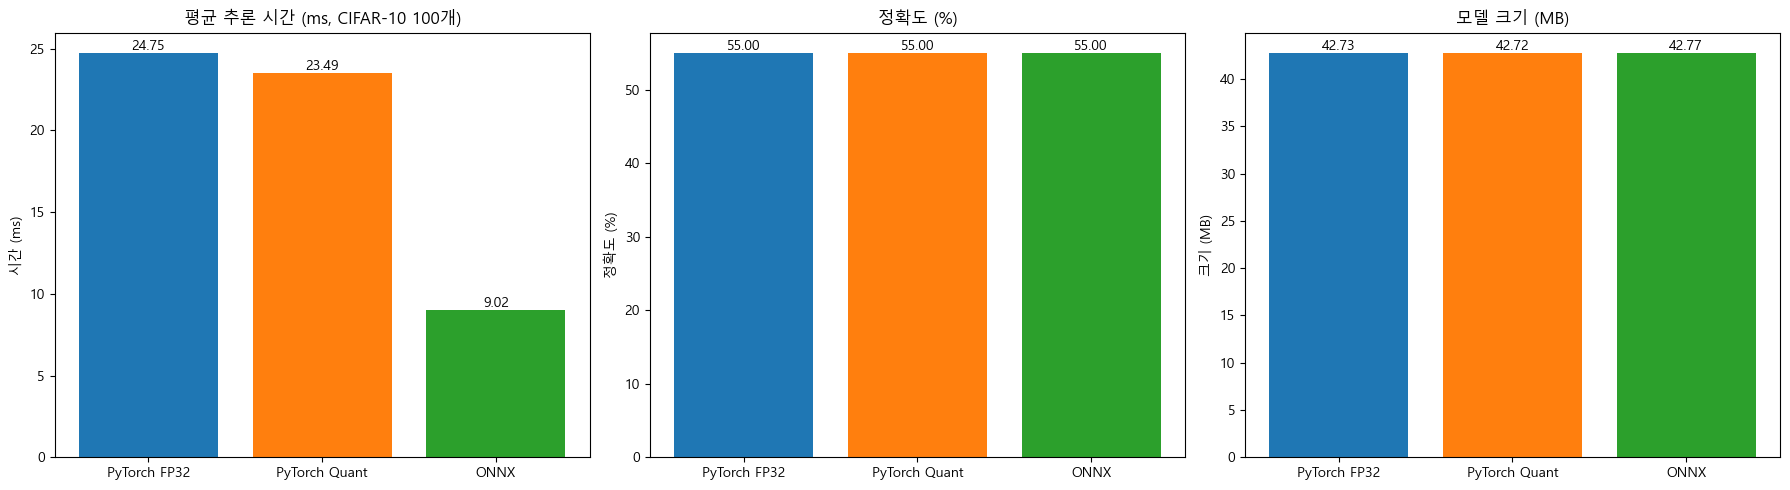

✅ 그래프 저장: outputs/plots/model_comparison.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# 시각화
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')
os.makedirs('outputs/plots', exist_ok=True)

models_order = list(results.keys())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. 추론 시간
times = [results[m]['avg_time_ms'] for m in models_order]
bars1 = ax1.bar(models_order, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('평균 추론 시간 (ms, CIFAR-10 100개)')
ax1.set_ylabel('시간 (ms)')
ax1.tick_params(axis='x', rotation=0)
ax1.bar_label(bars1, fmt='%.2f')

# 2. 정확도
accuracies = [results[m]['accuracy_%'] for m in models_order]
bars2 = ax2.bar(models_order, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('정확도 (%)')
ax2.set_ylabel('정확도 (%)')
ax2.tick_params(axis='x', rotation=0)
ax2.bar_label(bars2, fmt='%.2f')

# 3. 모델 크기
sizes = [model_sizes[m] for m in models_order]
bars3 = ax3.bar(models_order, sizes, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax3.set_title('모델 크기 (MB)')
ax3.set_ylabel('크기 (MB)')
ax3.tick_params(axis='x', rotation=0)
ax3.bar_label(bars3, fmt='%.2f')

plt.tight_layout()
plt.savefig('outputs/plots/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 그래프 저장: outputs/plots/model_comparison.png")